In [1]:
library(Seurat)
library(UCell)
library(dplyr)
library(ggplot2)
library(escape)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
so <- readRDS('pep_rich_cluster.rds')

# DEGs

In [3]:
treatments <- c('TWS-119_1_uM','UK5099_12.5_uM','UK5099_25_uM','UK5099_50_uM')

In [9]:
bw3446_degs <- lapply(treatments, function(x){
    so_subset <- subset(so, Donor == 'BW3446')
    degs <- FindMarkers(so_subset, `ident.1` = x, `ident.2` = 'DMSO_NA', group.by = 'Stemness_Concentration', test.use = 'MAST')
    return(degs)
})
names(bw3446_degs) <- treatments


Done!

Combining coefficients and standard errors

Calculating log-fold changes

Calculating likelihood ratio tests

Refitting on reduced model...


Done!


Done!

Combining coefficients and standard errors

Calculating log-fold changes

Calculating likelihood ratio tests

Refitting on reduced model...


Done!


Done!

Combining coefficients and standard errors

Calculating log-fold changes

Calculating likelihood ratio tests

Refitting on reduced model...


Done!


Done!

Combining coefficients and standard errors

Calculating log-fold changes

Calculating likelihood ratio tests

Refitting on reduced model...


Done!



In [10]:
saveRDS(bw3446_degs, 'bw3446_degs.rds')

In [ ]:
bw2164_degs <- lapply(treatments, function(x){
    so_subset <- subset(so, Donor == 'BW2164')
    degs <- FindMarkers(so_subset, `ident.1` = x, `ident.2` = 'DMSO_NA', group.by = 'Stemness_Concentration', test.use = 'MAST')
    return(degs)
})
names(bw2164_degs) <- treatments

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 1.2 GiB”

Done!

Combining coefficients and standard errors

Calculating log-fold changes

Calculating likelihood ratio tests

Refitting on reduced model...


Done!

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 1.1 GiB”

Done!

Combining coefficients and standard errors

Calculating log-fold changes

Calculating likelihood ratio tests

Refitting on reduced model...



In [8]:
saveRDS(bw2164_degs, 'bw2164_degs.rds')

# Pathways 

In [2]:
bw3446_degs <- readRDS('bw3446_degs.rds')
bw2164_degs <- readRDS('bw2164_degs.rds')

In [3]:
library(fgsea)
library(ggrepel)

In [4]:
# Read GMT file in as list of gene sets
# Based on code form GSEABase
readGMT <- function(fp, sep = "\t", ...){
    assertthat::assert_that(file.exists(fp), 
                           msg = sprintf("Could not locate input file %s", fp))
    assertthat::assert_that(grepl(".gmt$", fp),
                            msg = sprintf("Expecting file extension '.gmt'. Input file: %s", fp))
    
    lines <- strsplit(readLines(fp, ...), sep)
    gene_list <- lapply(lines, function(line) {
        unlist(line[-(1:2)])
    })
    names(gene_list) <- sapply(lines, "[[",1)
    gene_list                    
}

In [5]:
rank_genes_func <- function(x){
    # subset significant genes
    x <- subset(x, p_val_adj < 0.05)
    # compute ranking
    gene_list <- -log10(x$p_val_adj)*sign(x$avg_log2FC)
    names(gene_list) <- rownames(x)
    # handle inf values
    gene_list[is.infinite(gene_list) & gene_list > 0] <- 500
    gene_list[is.infinite(gene_list) & gene_list < 0] <- -500

    # sort decreasing values
    sorted_gene_list <- sort(gene_list, decreasing = T)
    return(sorted_gene_list)
    }

In [6]:
# read in all gene sets and merge into one master list
hallmark_fp <- "h.all.v2024.1.Hs.symbols.gmt"
hallmark_gs <- readGMT(hallmark_fp)

length(hallmark_gs)

gobp_fp <- "c5.go.bp.v2026.1.Hs.symbols.gmt"
gobp_gs <- readGMT(gobp_fp)

length(gobp_gs)

gocc_fp <- "c5.go.cc.v2026.1.Hs.symbols.gmt"
gocc_gs <- readGMT(gocc_fp)

length(gocc_gs)

[1] 50

[1] 7538

[1] 1080

In [7]:
bw3446_pathways <- lapply(names(bw3446_degs), function(x){
    ranked_genes <- rank_genes_func(bw3446_degs[[x]])
    fgsea_res <- fgsea(pathways=c(hallmark_gs, gobp_gs, gocc_gs),
                   stats=ranked_genes,
                   nPermSimple=10000)
})
names(bw3446_pathways) <- names(bw3446_degs)

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.03% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.19% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”


In [8]:
bw2164_pathways <- lapply(names(bw2164_degs), function(x){
    ranked_genes <- rank_genes_func(bw2164_degs[[x]])
    fgsea_res <- fgsea(pathways=c(hallmark_gs, gobp_gs, gocc_gs),
                   stats=ranked_genes,
                   nPermSimple=10000)
})
names(bw2164_pathways) <- names(bw2164_degs)

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.05% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.16% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.27% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (1.22% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”


In [9]:
bw3446_pathways_merge <- bind_rows(bw3446_pathways, .id = 'Treatment')
bw3446_pathways_merge$Donor <- 'BW3446'
bw2164_pathways_merge <- bind_rows(bw2164_pathways, .id = 'Treatment')
bw2164_pathways_merge$Donor <- 'BW2164'

In [10]:
pathways_merge <- rbind(bw3446_pathways_merge, bw2164_pathways_merge)

In [11]:
pathways_merge$Significant <- NA
pathways_merge$Significant[pathways_merge$padj < 0.05] <- '*'

In [12]:
pathways_merge %>%
    filter(NES > 0) %>%
    group_by(Donor, Treatment) %>%
    slice_min(order_by = padj, n = 5, with_ties = FALSE) %>%
    ungroup() %>%
    as.data.frame()

Treatment,pathway,pval,padj,log2err,ES,NES,size,leadingEdge,Donor,Significant
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<list>,<chr>,<chr>
TWS-119_1_uM,GOBP_POSITIVE_REGULATION_OF_IMMUNE_SYSTEM_PROCESS,6.920668e-07,1.485940e-04,0.6594444,0.3255591,1.683036,426,"NLRC5, P....",BW2164,*
TWS-119_1_uM,GOBP_CYTOKINE_MEDIATED_SIGNALING_PATHWAY,1.028673e-06,2.098237e-04,0.6435518,0.4576056,2.097592,166,"CXCR6, C....",BW2164,*
TWS-119_1_uM,GOBP_CALCIUM_MEDIATED_SIGNALING,1.512998e-06,2.939180e-04,0.6435518,0.5778148,2.325205,75,"CXCR6, R....",BW2164,*
TWS-119_1_uM,GOBP_REGULATION_OF_IMMUNE_RESPONSE,1.760508e-06,3.095110e-04,0.6435518,0.3413262,1.733165,370,"NLRC5, P....",BW2164,*
TWS-119_1_uM,GOCC_EXTERNAL_SIDE_OF_PLASMA_MEMBRANE,1.787539e-06,3.095110e-04,0.6435518,0.5334454,2.232821,92,"CXCR6, C....",BW2164,*
UK5099_12.5_uM,GOCC_CYTOPLASMIC_SIDE_OF_MITOCHONDRIAL_OUTER_MEMBRANE,3.649213e-05,4.006315e-02,0.5573322,0.9965209,1.472737,2,GRK2,BW2164,*
UK5099_12.5_uM,GOBP_CATECHOLAMINE_TRANSPORT,2.465087e-04,1.147728e-01,0.4984931,0.9295027,1.744571,7,GRK2,BW2164,NA
UK5099_12.5_uM,GOBP_MONOAMINE_TRANSPORT,3.029026e-04,1.225161e-01,0.4984931,0.9243023,1.787917,8,GRK2,BW2164,NA
UK5099_12.5_uM,GOBP_CATECHOLAMINE_SECRETION,3.586377e-04,1.312443e-01,0.4984931,0.9390955,1.707514,6,GRK2,BW2164,NA


In [13]:
top_up_pathways <- pathways_merge %>%
    filter(Treatment %in% c('TWS-119_1_uM','UK5099_50_uM')) %>%
    filter(NES > 0) %>%
    group_by(Donor, Treatment) %>%
    slice_min(order_by = padj, n = 5, with_ties = FALSE) %>%
    ungroup() %>%
    as.data.frame() %>%
    select(pathway) %>%
    unique()

In [14]:
length(unique(top_up_pathways$pathway))

[1] 18

In [15]:
pathways_merge %>%
    filter(NES < 0) %>%
    slice_min(order_by = padj, n=25, with_ties = FALSE)

Treatment,pathway,pval,padj,log2err,ES,NES,size,leadingEdge,Donor,Significant
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<list>,<chr>,<chr>
TWS-119_1_uM,GOBP_CELL_CYCLE_PROCESS,1.684837e-34,1.316869e-30,1.529705,-0.6540432,-2.343762,542,"ACTB, FL....",BW3446,*
TWS-119_1_uM,GOBP_DNA_METABOLIC_PROCESS,1.029109e-29,4.021758e-26,1.417276,-0.6654481,-2.343092,424,"ACTB, MC....",BW3446,*
TWS-119_1_uM,HALLMARK_E2F_TARGETS,2.124516e-29,5.535073e-26,1.409951,-0.8099388,-2.603014,162,"MCM5, HE....",BW3446,*
TWS-119_1_uM,GOBP_CELL_CYCLE,5.605435e-29,1.095302e-25,1.395187,-0.6003635,-2.175982,643,"ACTB, FL....",BW3446,*
TWS-119_1_uM,GOBP_MITOTIC_CELL_CYCLE,2.716437e-26,4.246334e-23,1.326716,-0.6513132,-2.285657,400,"ACTB, FL....",BW3446,*
TWS-119_1_uM,GOBP_CHROMOSOME_ORGANIZATION,6.344031e-26,8.264158e-23,1.318889,-0.7062279,-2.406172,286,"ACTB, FL....",BW3446,*
TWS-119_1_uM,GOBP_MITOTIC_CELL_CYCLE_PROCESS,1.015447e-25,1.133820e-22,1.318889,-0.6745067,-2.343496,354,"ACTB, FL....",BW3446,*
TWS-119_1_uM,GOBP_DNA_REPAIR,5.546164e-24,5.418602e-21,1.270913,-0.6962059,-2.363755,275,"ACTB, MC....",BW3446,*
TWS-119_1_uM,GOCC_CHROMOSOMAL_REGION,2.545606e-22,2.210717e-19,1.221054,-0.7265984,-2.417224,219,"ACTB, MC....",BW3446,*


In [16]:
top_down_pathways <- pathways_merge %>%
    filter(Treatment %in% c('TWS-119_1_uM','UK5099_50_uM')) %>%
    filter(NES < 0) %>%
    group_by(Donor, Treatment) %>%
    slice_min(order_by = padj, n = 5, with_ties = FALSE) %>%
    ungroup() %>%
    as.data.frame() %>%
    select(pathway) %>%
    unique()

In [28]:
top_pathways <- c(top_up_pathways$pathway, top_down_pathways$pathway)
sort(top_pathways)

[1] "GOBP_ALPHA_BETA_T_CELL_ACTIVATION"                                             
 [2] "GOBP_AMINO_ACID_IMPORT_ACROSS_PLASMA_MEMBRANE"                                 
 [3] "GOBP_BIOLOGICAL_PROCESS_INVOLVED_IN_INTERSPECIES_INTERACTION_BETWEEN_ORGANISMS"
 [4] "GOBP_CALCIUM_MEDIATED_SIGNALING"                                               
 [5] "GOBP_CANONICAL_NF_KAPPAB_SIGNAL_TRANSDUCTION"                                  
 [6] "GOBP_CELLULAR_RESPIRATION"                                                     
 [7] "GOBP_CELL_CYCLE"                                                               
 [8] "GOBP_CELL_CYCLE_PROCESS"                                                       
 [9] "GOBP_CYTOKINE_MEDIATED_SIGNALING_PATHWAY"                                      
[10] "GOBP_DEFENSE_RESPONSE_TO_OTHER_ORGANISM"                                       
[11] "GOBP_DEFENSE_RESPONSE_TO_VIRUS"                                                
[12] "GOBP_DNA_METABOLIC_PROCESS"                                                    
[13] "GOBP_GENERATION_OF_PRECURSOR_METABOLITES_AND_ENERGY"                           
[14] "GOBP_LIPID_BIOSYNTHETIC_PROCESS"                                               
[15] "GOBP_MITOTIC_CELL_CYCLE"                                                       
[16] "GOBP_NEUTRAL_AMINO_ACID_TRANSPORT"                                             
[17] "GOBP_ORGANOPHOSPHATE_METABOLIC_PROCESS"                                        
[18] "GOBP_OXIDATIVE_PHOSPHORYLATION"                                                
[19] "GOBP_POSITIVE_REGULATION_OF_IMMUNE_SYSTEM_PROCESS"                             
[20] "GOBP_POSITIVE_REGULATION_OF_SIGNALING"                                         
[21] "GOBP_PROTON_TRANSMEMBRANE_TRANSPORT"                                           
[22] "GOBP_REGULATION_OF_IMMUNE_RESPONSE"                                            
[23] "GOBP_REGULATION_OF_IMMUNE_SYSTEM_PROCESS"                                      
[24] "GOBP_RESPONSE_TO_VIRUS"                                                        
[25] "GOBP_SMALL_MOLECULE_BIOSYNTHETIC_PROCESS"                                      
[26] "GOBP_SMALL_MOLECULE_METABOLIC_PROCESS"                                         
[27] "GOBP_STEROL_BIOSYNTHETIC_PROCESS"                                              
[28] "GOBP_T_CELL_RECEPTOR_SIGNALING_PATHWAY"                                        
[29] "GOCC_EXTERNAL_SIDE_OF_PLASMA_MEMBRANE"                                         
[30] "GOCC_MITOCHONDRION"                                                            
[31] "GOCC_ORGANELLE_INNER_MEMBRANE"                                                 
[32] "HALLMARK_CHOLESTEROL_HOMEOSTASIS"                                              
[33] "HALLMARK_E2F_TARGETS"                                                          
[34] "HALLMARK_INTERFERON_GAMMA_RESPONSE"                                            
[35] "HALLMARK_MYC_TARGETS_V1"                                                       
[36] "HALLMARK_TNFA_SIGNALING_VIA_NFKB"

In [18]:
library(tidyr)
library(ComplexHeatmap)

Loading required package: grid

ComplexHeatmap version 2.22.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))




In [19]:
wide_df <- pathways_merge %>%
  filter(pathway %in% top_pathways) %>%
  unite("ID", Donor, Treatment, sep = " | ") %>%
  select(ID, pathway, NES) %>%
  pivot_wider(names_from = ID, values_from = NES) %>%
  tibble::column_to_rownames("pathway")

mat <- as.matrix(wide_df)

In [21]:
sig_mat <- pathways_merge %>%
  filter(pathway %in% top_pathways) %>%
  unite("ID", Donor, Treatment, sep = " | ") %>%
  select(ID, pathway, Significant) %>%
  pivot_wider(names_from = ID, values_from = Significant) %>%
  tibble::column_to_rownames("pathway") %>%
  as.matrix()

col_fun = circlize::colorRamp2(
  c(min(mat, na.rm = TRUE), 0, max(mat, na.rm = TRUE)), 
  c("blue", "white", "red")
)

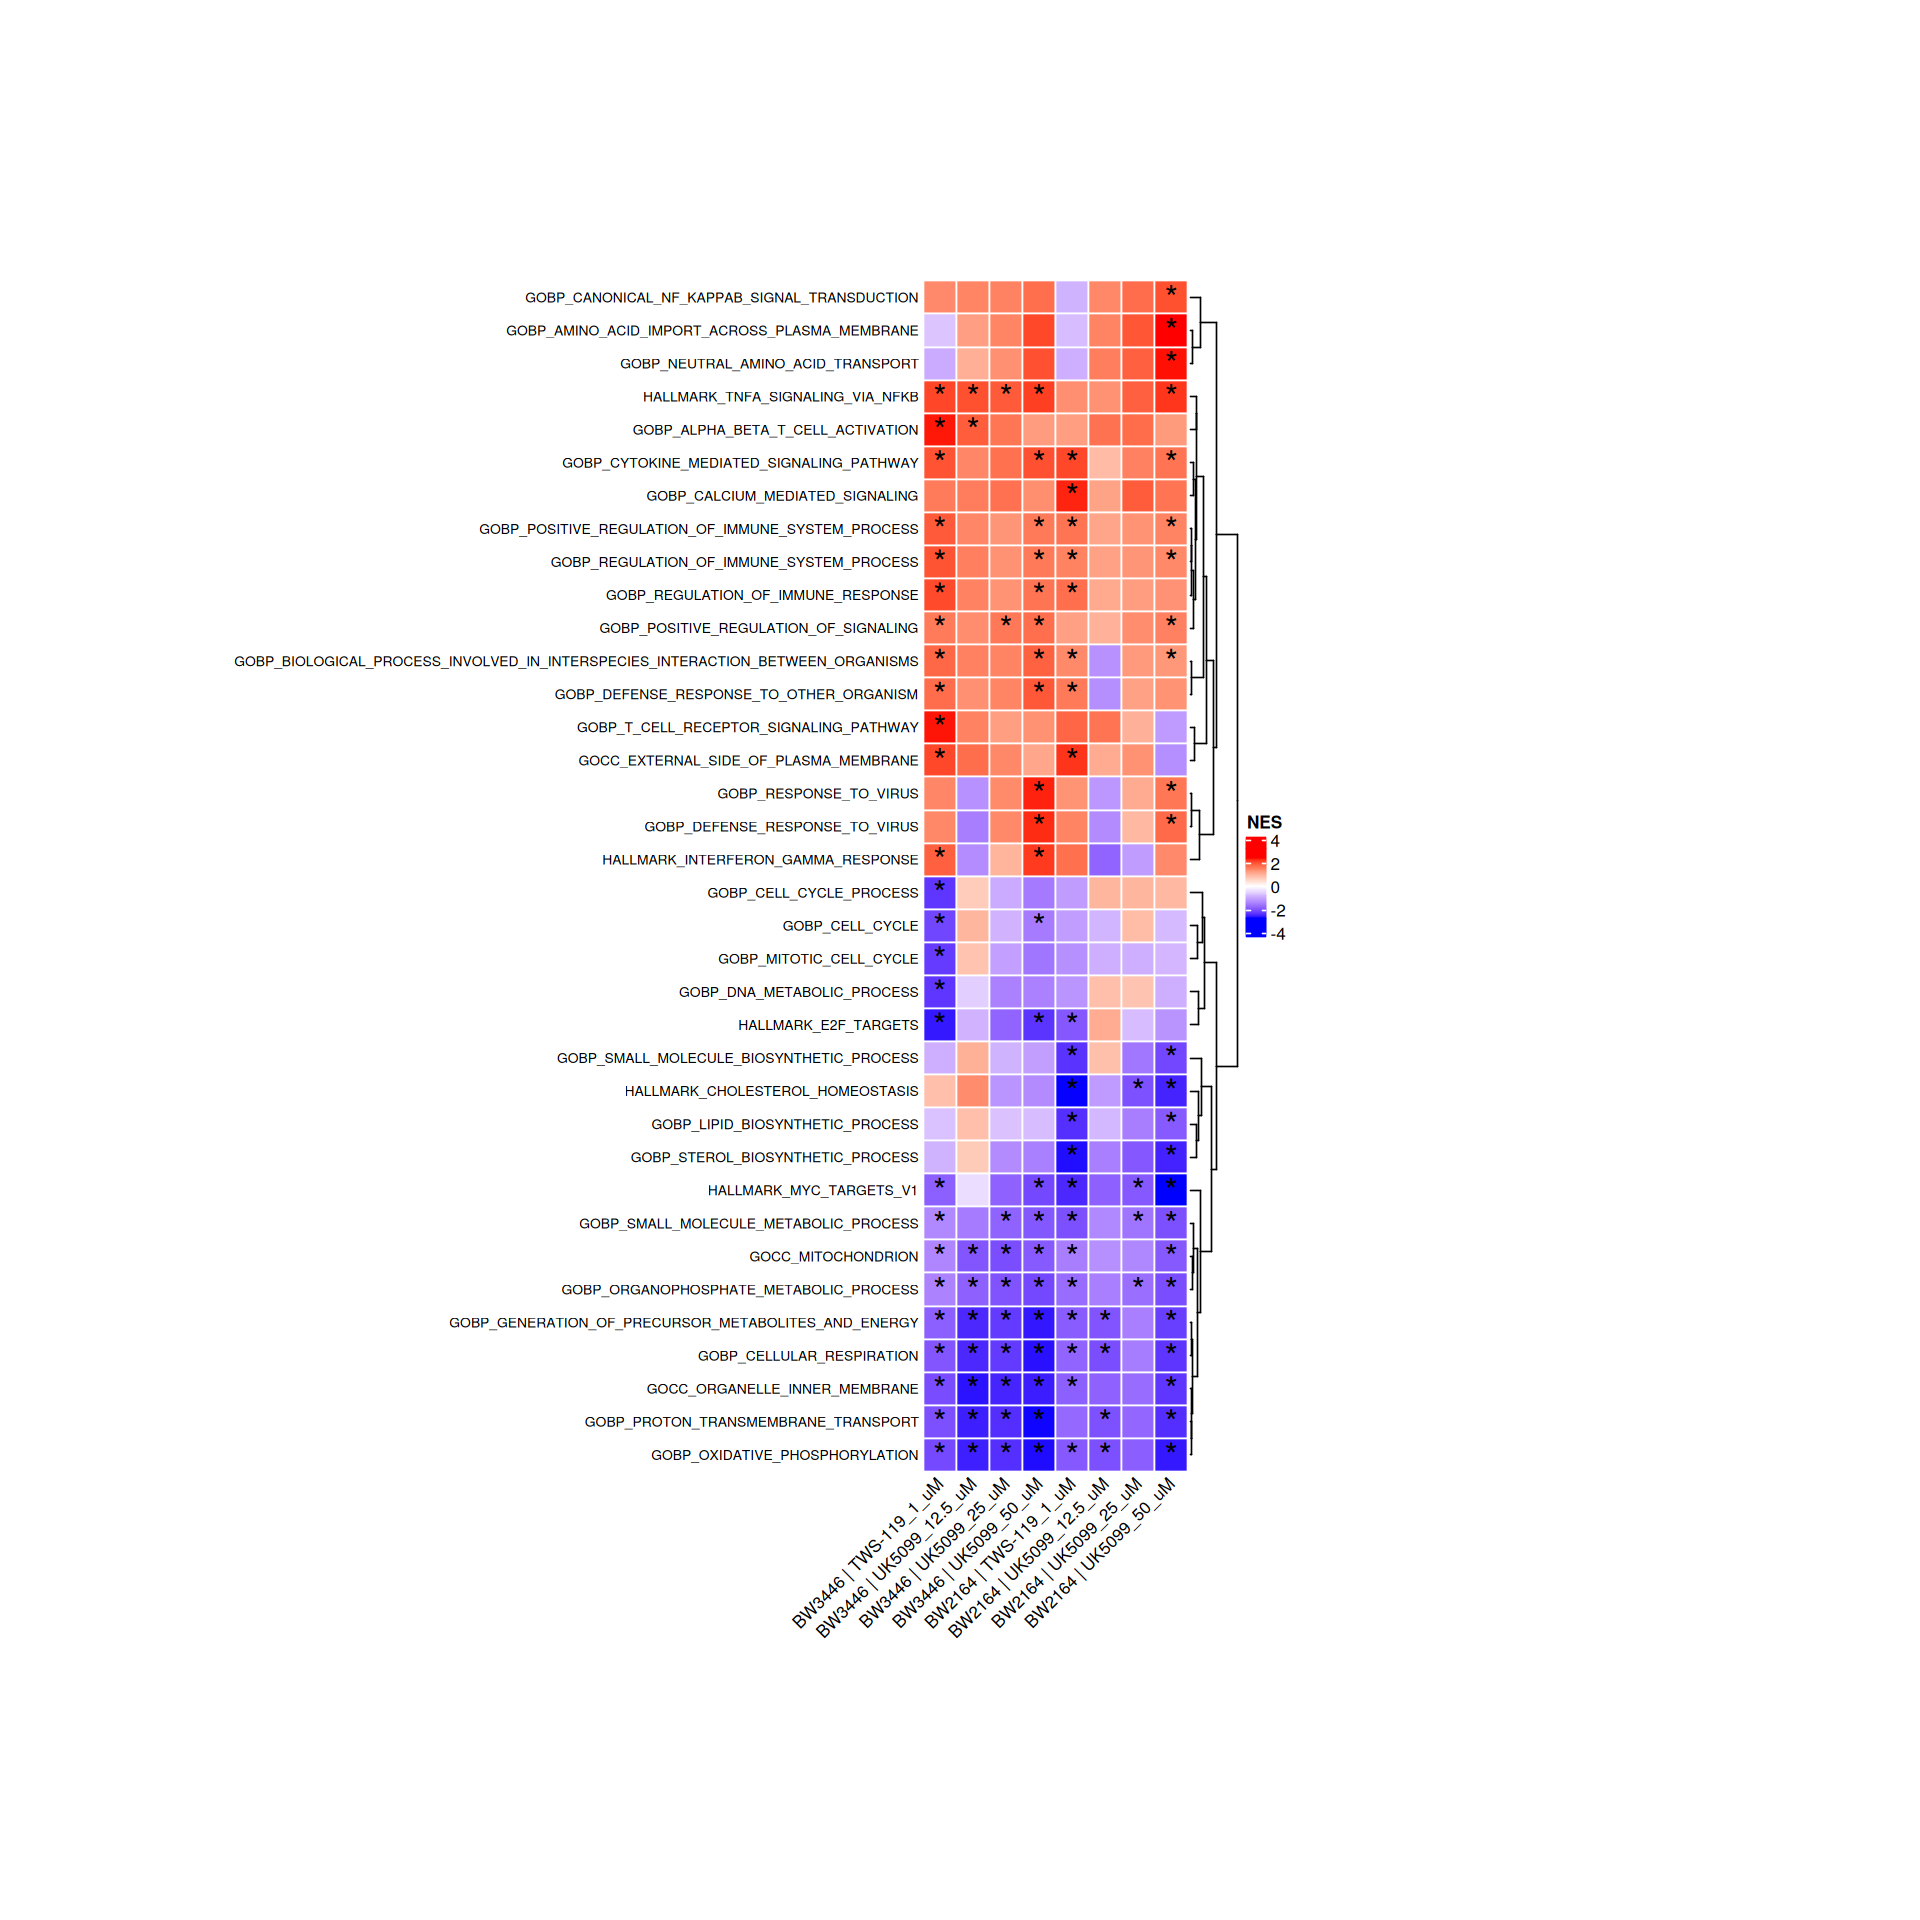

In [23]:
options(repr.plot.width = 16, repr.plot.height = 16)

Heatmap(mat, 
        name = "NES",
        col = col_fun,
        row_names_side = "left",
        row_dend_side = "right",
        cluster_rows = TRUE, 
        cluster_columns = FALSE,
        width = unit(ncol(mat)*7, "mm"), 
        height = unit(nrow(mat)*7, "mm"),
        rect_gp = gpar(col = "white", lwd = 1), 
        column_names_gp = gpar(fontsize = 10),
        row_names_gp = gpar(fontsize = 8),
        column_names_rot = 45,
        cell_fun = function(j, i, x, y, width, height, fill) {
          label <- sig_mat[i, j]
          if(!is.na(label)) {
            grid.text(label, x, y, gp = gpar(fontsize = 20))
          }
        })

In [25]:
library(stringr)
wrap_labels <- function(labels, width = 30) {
  str_wrap(gsub("_", " ", labels), width = width) 
}

In [26]:
rownames(mat) <- wrap_labels(rownames(mat), width = 25)
rownames(sig_mat) <- rownames(mat)

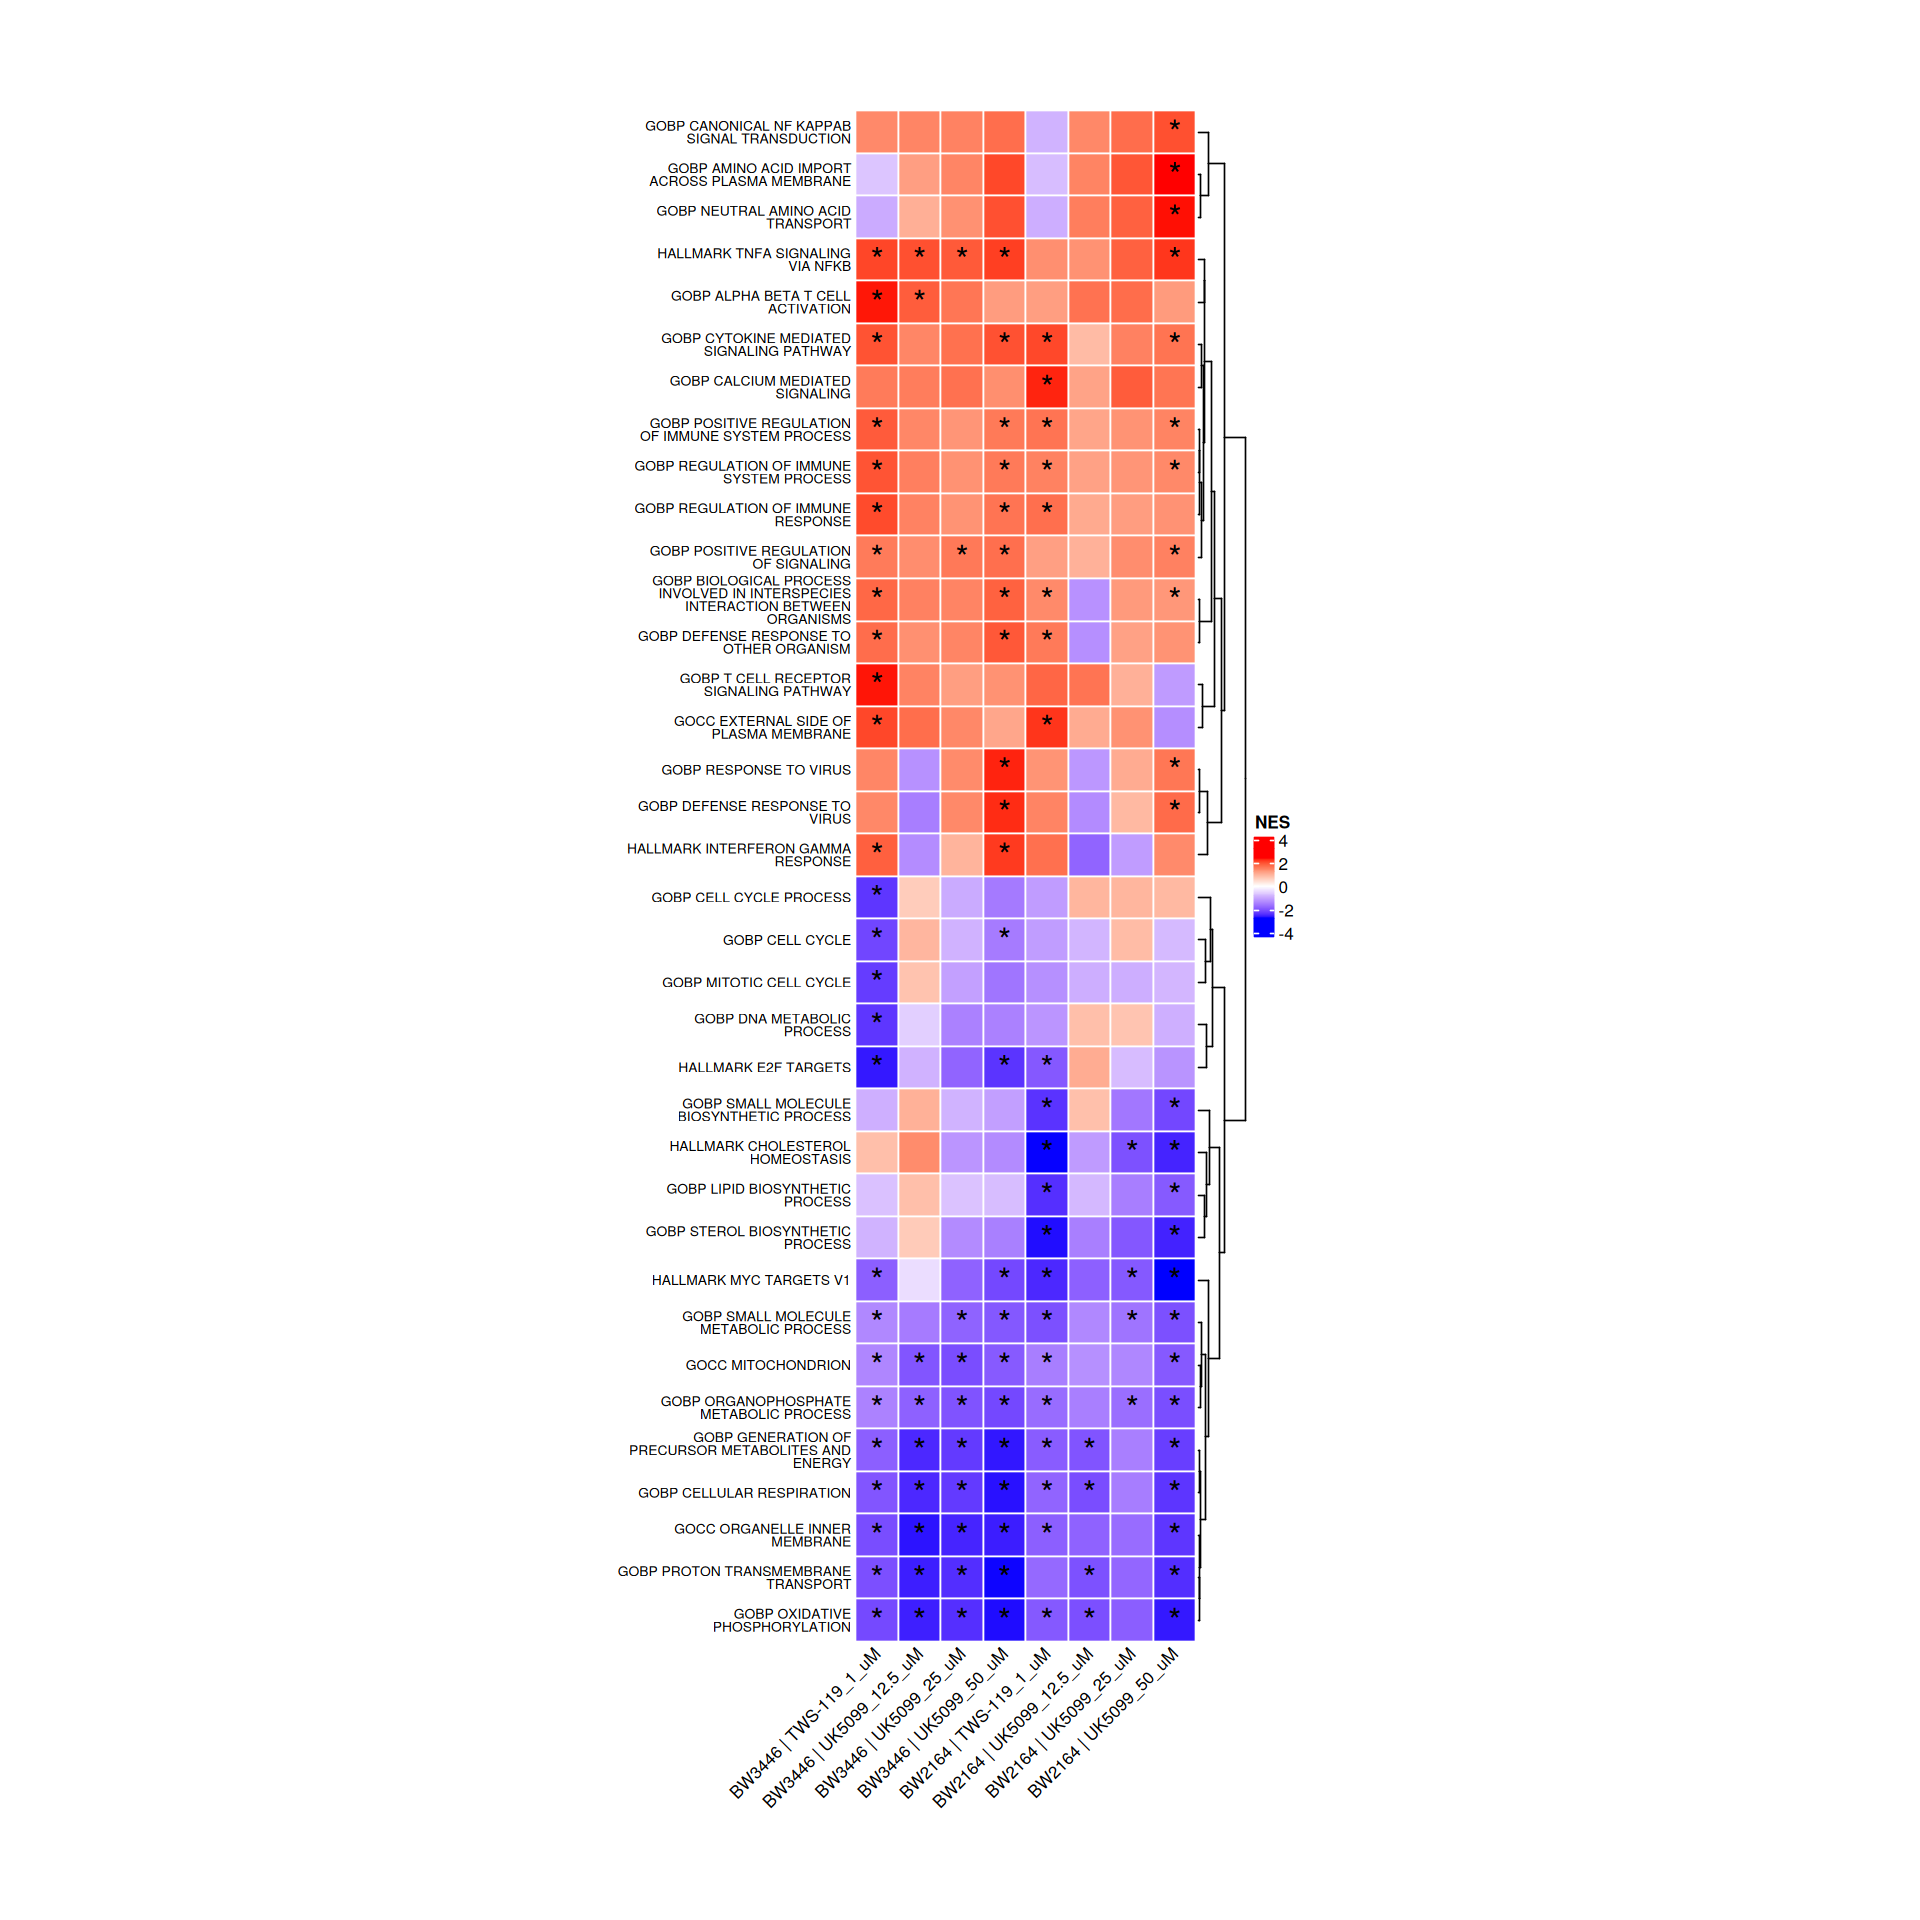

In [27]:
Heatmap(mat, 
        name = "NES",
        col = col_fun,
        row_names_side = "left",
        row_names_gp = gpar(fontsize = 8, lineheight = 0.8),
        row_names_max_width = unit(6, "cm"),
        row_dend_side = "right",
        cluster_rows = TRUE, 
        cluster_columns = FALSE,
        width = unit(ncol(mat)*9, "mm"), 
        height = unit(nrow(mat)*9, "mm"),
        rect_gp = gpar(col = "white", lwd = 1), 
        column_names_gp = gpar(fontsize = 10),
        # row_names_gp = gpar(fontsize = 8),
        column_names_rot = 45,
        cell_fun = function(j, i, x, y, width, height, fill) {
          label <- sig_mat[i, j]
          if(!is.na(label)) {
            grid.text(label, x, y, gp = gpar(fontsize = 20))
          }
        })

In [31]:
# Open the PDF graphics device
pdf("plots/Fig2h_pathway_heatmap.pdf", width = 16, height = 16) # You can specify width and height in inches

# Create your plot
Heatmap(mat, 
        name = "NES",
        col = col_fun,
        row_names_side = "left",
        row_names_gp = gpar(fontsize = 8, lineheight = 0.8),
        row_names_max_width = unit(6, "cm"),
        row_dend_side = "right",
        cluster_rows = TRUE, 
        cluster_columns = FALSE,
        width = unit(ncol(mat)*9, "mm"), 
        height = unit(nrow(mat)*9, "mm"),
        rect_gp = gpar(col = "white", lwd = 1), 
        column_names_gp = gpar(fontsize = 10),
        # row_names_gp = gpar(fontsize = 8),
        column_names_rot = 45,
        cell_fun = function(j, i, x, y, width, height, fill) {
          label <- sig_mat[i, j]
          if(!is.na(label)) {
            grid.text(label, x, y, gp = gpar(fontsize = 20))
          }
        })

# Close the graphics device to save the plot
dev.off()

agg_record_946413672 
                   2

# UCell

In [102]:
merged_pathway_list <- c(hallmark_gs, gobp_gs, gocc_gs)

In [103]:
length(merged_pathway_list[top_pathways])

[1] 35

In [104]:
so <- AddModuleScore_UCell(so, features = merged_pathway_list[top_pathways], chunk.size = 200000, ncores = 4, maxRank = 2000)

Warning message:
“The following genes were not found and will be
                        imputed to exp=0:
* BIRC8,CARD8,CASP1,CNTF,DUOX1,EIF5A,EPOR,GPR75,H2BC11,IFNA10,IFNA17,IFNL3,IFNL4,IL17RE,LILRA3,LILRB3,LIMS1,MIR101-1,MIR1246,MIR125A,MIR125B1,MIR130A,MIR135A1,MIR146A,MIR152,MIR20A,MIR21,MIR24-1,MIR26A1,MIR27A,MIR27B,MIR29B1,MIR34A,MIR520C,MIR98,MIR99A,MIRLET7A1,MIRLET7C,MIRLET7E,RPS6KA4,RPS6KA5,TREX1,ABHD17A,BTN2A3P,BTNL10P,BTNL9,C4A,CD8B,CFHR1,CLECL1P,DEFB131A,FCN1,GPR32P1,HCAR2,HLA-A,HLA-B,HLA-C,HLA-DMA,HLA-DMB,HLA-DOA,HLA-DOB,HLA-DPA1,HLA-DPB1,HLA-DQA1,HLA-DQA2,HLA-DQB1,HLA-DQB2,HLA-DRA,HLA-DRB1,HLA-DRB3,HLA-DRB4,HLA-DRB5,HLA-E,HLA-F,HLA-G,HLA-H,HMGB1,ICOSLG,IGF2,IGHG2,IGHG4,IGLC3,IGLC6,KIR2DS2,KLRC2,KLRC4-KLRK1,MATR3,MIR136,MIR140,MIR142,MIR145,MIR149,MIR17,MIR18A,MIR19A,MIR200B,MIR200C,MIR210,MIR30B,MIR4691,MIR486-1,MIR520B,MIR520E,MIR708,MR1,PYDC5,RPS19,RPS6KA3,S100A7,BHLHA15,FKBP1A,GSTM2,MIR1-1,MIR133A1,NUDT4,APLF,CD300H,FCGR2C,GNAS,GPX1,KIR2DL1,KIR2DL2,KIR2DL3,KIR2DL5A,KI

In [105]:
saveRDS(so, 'vst3_ucell_select_pathways.rds')

In [32]:
so <- readRDS('vst3_ucell_select_pathways.rds')

In [33]:
sort(colnames(so@meta.data))

[1] "AIFI_PBMC.Flex_L1"                                                                   
  [2] "AIFI_PBMC.Flex_L2"                                                                   
  [3] "AIFI_PBMC.Flex_L3"                                                                   
  [4] "CTaa"                                                                                
  [5] "CTgene"                                                                              
  [6] "CTnt"                                                                                
  [7] "CTstrict"                                                                            
  [8] "Concentration"                                                                       
  [9] "Culture"                                                                             
 [10] "Day"                                                                                 
 [11] "Donor"                                                                               
 [12] "G2M.Score"                                                                           
 [13] "GOBP_ACTIVATION_OF_IMMUNE_RESPONSE_UCell"                                            
 [14] "GOBP_ADAPTIVE_IMMUNE_RESPONSE_UCell"                                                 
 [15] "GOBP_ALPHA_BETA_T_CELL_ACTIVATION_UCell"                                             
 [16] "GOBP_AMINO_ACID_IMPORT_ACROSS_PLASMA_MEMBRANE_UCell"                                 
 [17] "GOBP_ANTIGEN_RECEPTOR_MEDIATED_SIGNALING_PATHWAY_UCell"                              
 [18] "GOBP_BIOLOGICAL_PROCESS_INVOLVED_IN_INTERSPECIES_INTERACTION_BETWEEN_ORGANISMS_UCell"
 [19] "GOBP_CALCIUM_MEDIATED_SIGNALING_UCell"                                               
 [20] "GOBP_CANONICAL_NF_KAPPAB_SIGNAL_TRANSDUCTION_UCell"                                  
 [21] "GOBP_CELLULAR_RESPIRATION_UCell"                                                     
 [22] "GOBP_CELL_ACTIVATION_UCell"                                                          
 [23] "GOBP_CELL_CYCLE_PROCESS_UCell"                                                       
 [24] "GOBP_CELL_CYCLE_UCell"                                                               
 [25] "GOBP_CHROMOSOME_ORGANIZATION_UCell"                                                  
 [26] "GOBP_CHROMOSOME_SEGREGATION_UCell"                                                   
 [27] "GOBP_CYTOKINE_MEDIATED_SIGNALING_PATHWAY_UCell"                                      
 [28] "GOBP_DEFENSE_RESPONSE_TO_OTHER_ORGANISM_UCell"                                       
 [29] "GOBP_DEFENSE_RESPONSE_TO_VIRUS_UCell"                                                
 [30] "GOBP_DNA_DAMAGE_RESPONSE_UCell"                                                      
 [31] "GOBP_DNA_METABOLIC_PROCESS_UCell"                                                    
 [32] "GOBP_DNA_RECOMBINATION_UCell"                                                        
 [33] "GOBP_DNA_REPAIR_UCell"                                                               
 [34] "GOBP_DNA_REPLICATION_UCell"                                                          
 [35] "GOBP_DNA_TEMPLATED_DNA_REPLICATION_UCell"                                            
 [36] "GOBP_GENERATION_OF_PRECURSOR_METABOLITES_AND_ENERGY_UCell"                           
 [37] "GOBP_IMMUNE_RESPONSE_REGULATING_CELL_SURFACE_RECEPTOR_SIGNALING_PATHWAY_UCell"       
 [38] "GOBP_IMMUNE_RESPONSE_REGULATING_SIGNALING_PATHWAY_UCell"                             
 [39] "GOBP_INFLAMMATORY_RESPONSE_UCell"                                                    
 [40] "GOBP_LIPID_BIOSYNTHETIC_PROCESS_UCell"                                               
 [41] "GOBP_LYMPHOCYTE_ACTIVATION_UCell"                                                    
 [42] "GOBP_MITOTIC_CELL_CYCLE_PROCESS_UCell"                                               
 [43] "GOBP_MITOTIC_CELL_CYCLE_UCell"                                                       
 [4

In [42]:
plot_clonal_deltas <- function(seurat_obj, path_x, path_y, min_cells = 50, plot_title) {
  # summarise UCell values by clone
  clonal_projection <- seurat_obj@meta.data %>%
    filter(!is.na(CTaa), !is.na(Stemness)) %>%
    group_by(Donor, CTaa, Stemness_Concentration) %>%
    filter(n() >= min_cells) %>% 
    summarise(
      x_axis = median(.data[[path_x]], na.rm = TRUE),
      y_axis = median(.data[[path_y]], na.rm = TRUE),
      clone_size = n(),
      .groups = "drop"
    )
  
  # Extract baseline DMSO values
  baselines <- clonal_projection %>%
    filter(Stemness_Concentration == "DMSO_NA") %>%
    select(Donor, CTaa, x_base = x_axis, y_base = y_axis)
  
  # Calculate change from DMSO 
  delta_projection <- clonal_projection %>%
    inner_join(baselines, by = c("Donor", "CTaa")) %>%
    mutate(
      x_delta = x_axis - x_base,
      y_delta = y_axis - y_base
    ) %>%
    filter(Stemness_Concentration != "DMSO_NA")
  
  # extract max values for plot sizing
  x_max_val <- max(abs(delta_projection$x_delta), na.rm = TRUE)
  y_max_val <- max(abs(delta_projection$y_delta), na.rm = TRUE)
  plot_lim_x <- x_max_val * 1.05 
  plot_lim_y <- y_max_val * 1.05
  
  # plot
  ggplot(delta_projection, aes(x = x_delta, y = y_delta, color = Stemness_Concentration)) +
    geom_hline(yintercept = 0, linetype = "dashed", color = "gray70") +
    geom_vline(xintercept = 0, linetype = "dashed", color = "gray70") +
    geom_segment(aes(x = 0, y = 0, xend = x_delta, yend = y_delta),
                 arrow = arrow(length = unit(0.2, "cm"), type = "closed"),
                 alpha = 0.4, linewidth = 0.8) +
    geom_point(aes(size = clone_size), alpha = 0.7) +
    # Force axes to be equal and symmetric
    coord_cartesian(xlim = c(-plot_lim_x, plot_lim_x), 
                    ylim = c(-plot_lim_y, plot_lim_y)) +
    # scale_color_manual(values = c("TWS-119" = "royalblue", "UK5099" = "forestgreen")) +
    theme_minimal(base_size = 12) +
    labs(
      title = plot_title,
      # subtitle = paste("Baseline (0,0): DMSO | Clones >=", min_cells, "cells"),
      x = paste("Δ", gsub("_UCell", "", path_x)),
      y = paste("Δ", gsub("_UCell", "", path_y)),
      size = "Cells per Clone"
    ) + theme(legend.position = 'none', plot.title = element_text(size=20)) + facet_grid(cols = vars(Stemness_Concentration))
}

In [43]:
options(repr.plot.width = 18, repr.plot.height = 6)
p1 <- plot_clonal_deltas(seurat_obj = so, path_x = 'HALLMARK_MYC_TARGETS_V1_UCell',path_y = 'GOBP_CELL_CYCLE_PROCESS_UCell', plot_title = 'Cell Cycle')
p2 <- plot_clonal_deltas(seurat_obj = so, path_x = 'HALLMARK_TNFA_SIGNALING_VIA_NFKB_UCell',path_y = 'GOBP_RESPONSE_TO_VIRUS_UCell', plot_title = 'Immune Activation')
p3 <- plot_clonal_deltas(seurat_obj = so, path_x = 'GOBP_OXIDATIVE_PHOSPHORYLATION_UCell',path_y = 'GOCC_MITOCHONDRION_UCell', plot_title = 'Mitochondria & Energy Production')
p4 <- plot_clonal_deltas(seurat_obj = so, path_x = 'HALLMARK_CHOLESTEROL_HOMEOSTASIS_UCell',path_y = 'GOBP_SMALL_MOLECULE_METABOLIC_PROCESS_UCell', plot_title = 'Metabolism')

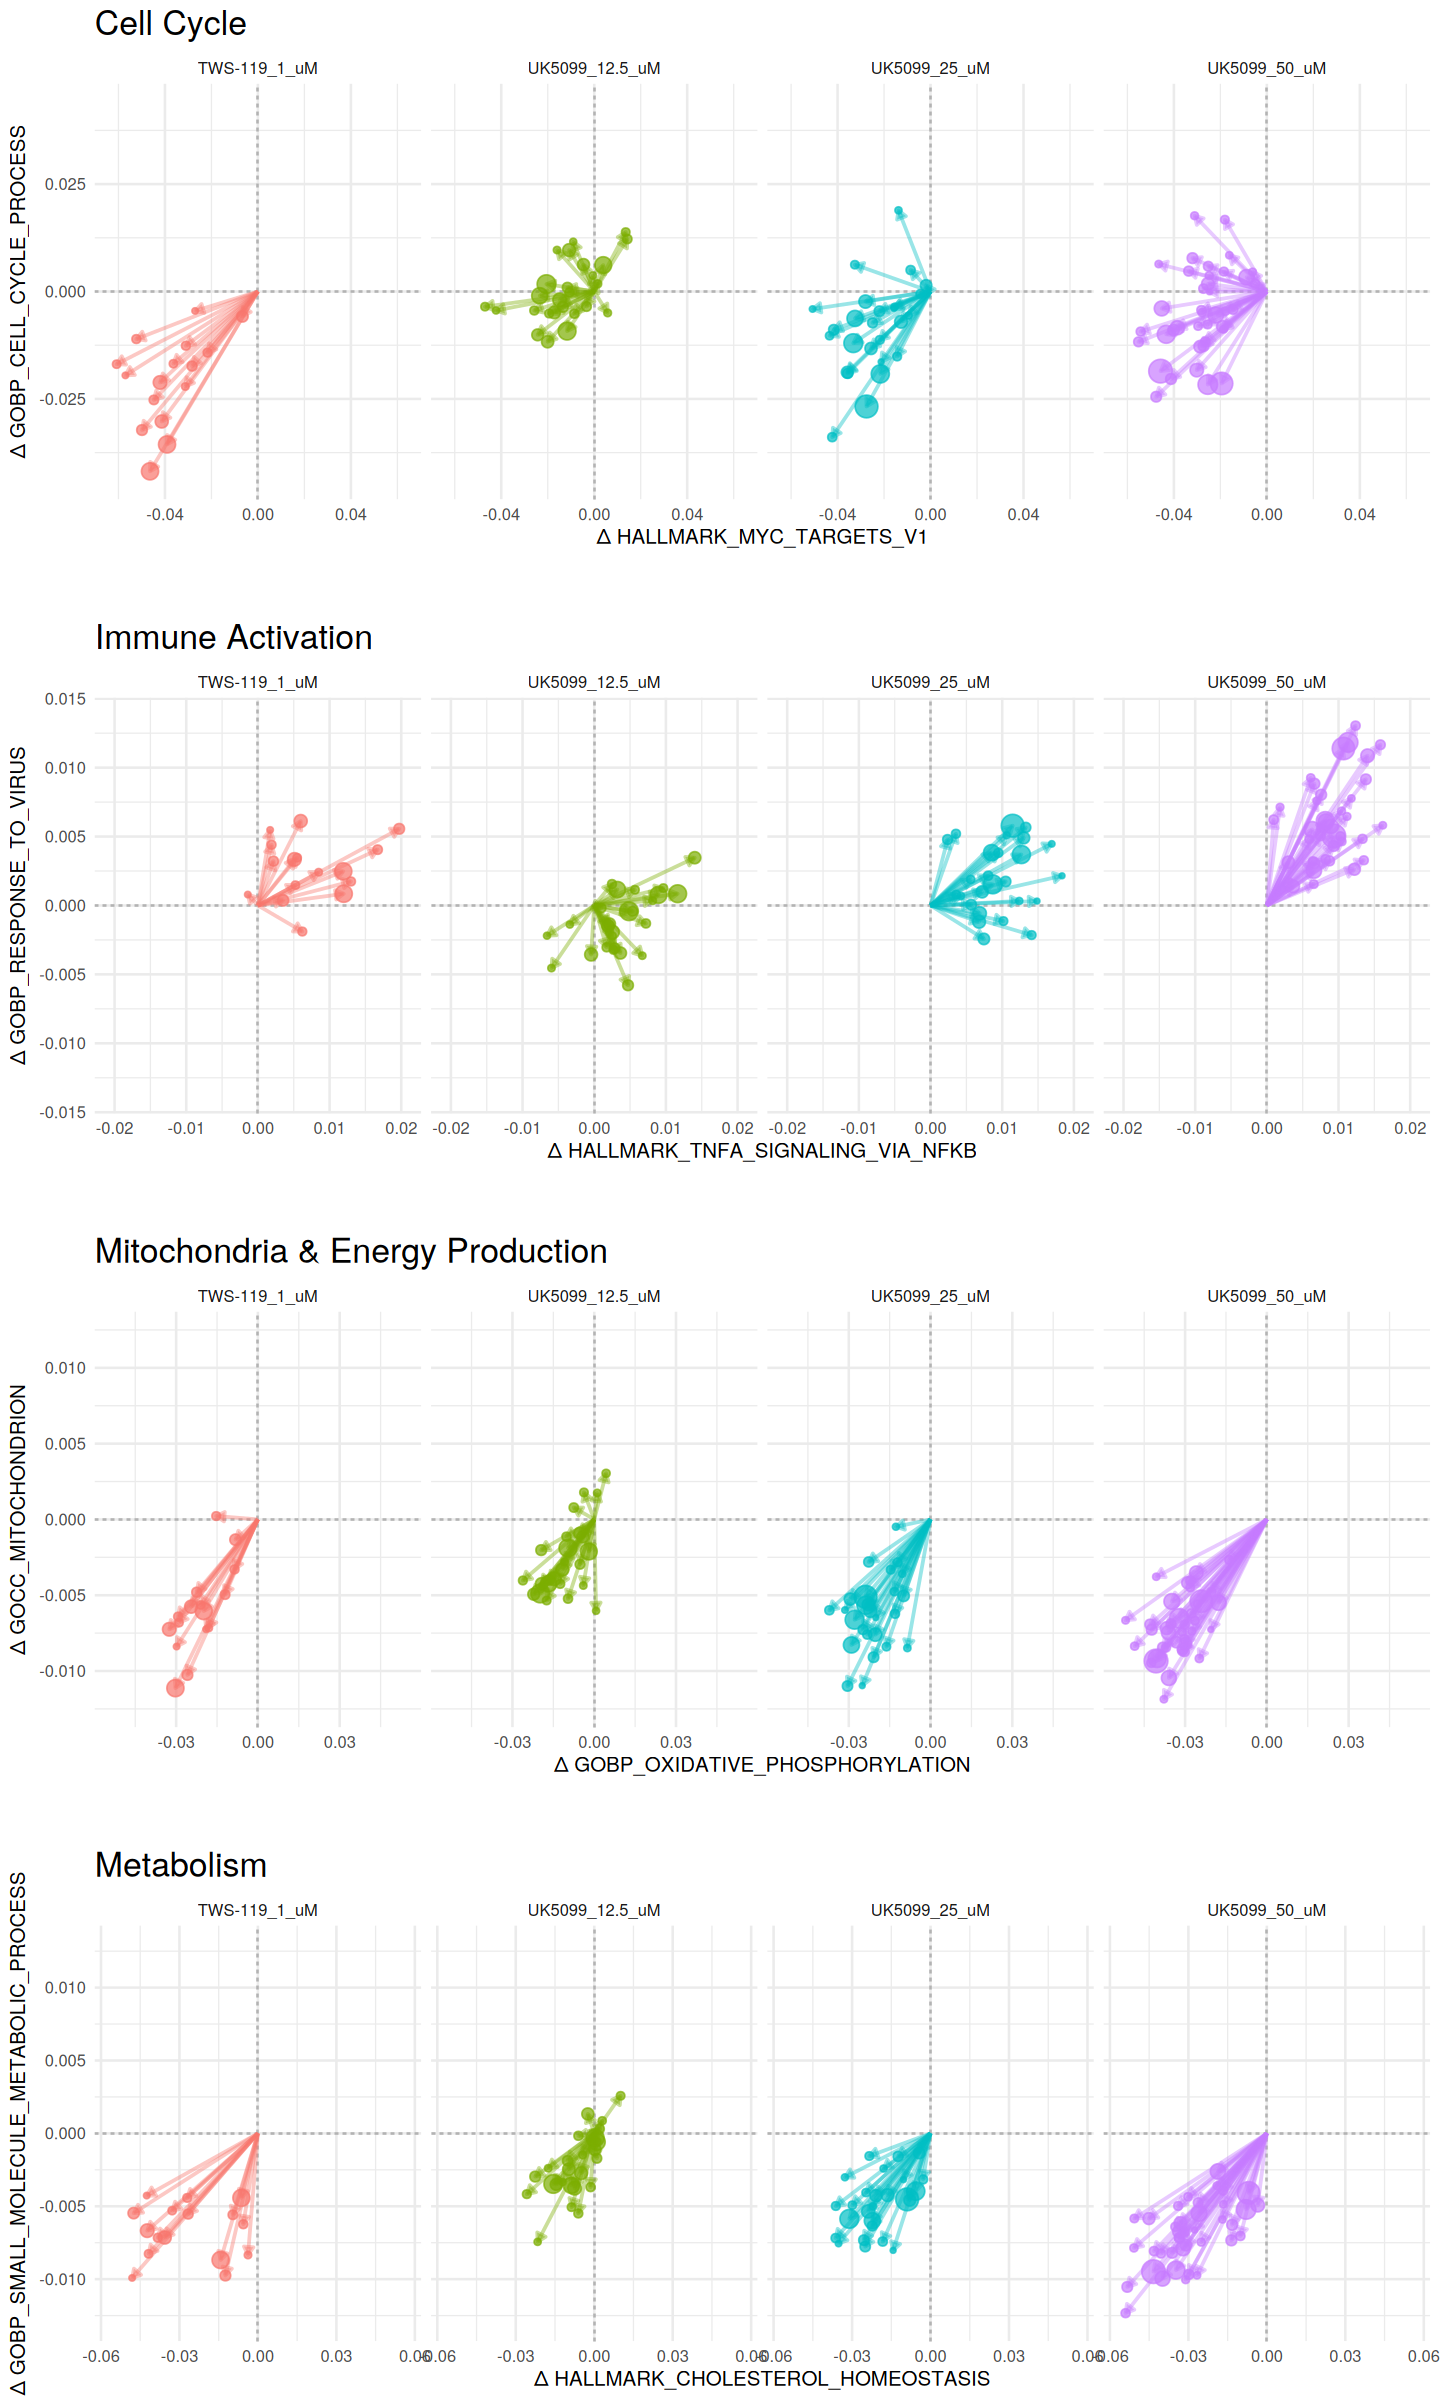

In [45]:
options(repr.plot.width = 12, repr.plot.height = 20)
cowplot::plot_grid(p1,NULL,p2,NULL,p3,NULL,p4,ncol=1, rel_heights = c(1,0.1,1,0.1,1,0.1,1))

In [46]:
# Open the PDF graphics device
pdf("plots/Fig2h_clone_dynamics.pdf", width = 12, height = 20) # You can specify width and height in inches

# Create your plot
cowplot::plot_grid(p1,NULL,p2,NULL,p3,NULL,p4,ncol=1, rel_heights = c(1,0.1,1,0.1,1,0.1,1))

# Close the graphics device to save the plot
dev.off()

Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Δ HALLMARK_MYC_TARGETS_V1' in 'mbcsToSbcs': for Δ (U+0394)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Δ GOBP_CELL_CYCLE_PROCESS' in 'mbcsToSbcs': for Δ (U+0394)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Δ HALLMARK_TNFA_SIGNALING_VIA_NFKB' in 'mbcsToSbcs': for Δ (U+0394)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Δ GOBP_RESPONSE_TO_VIRUS' in 'mbcsToSbcs': for Δ (U+0394)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Δ GOBP_OXIDATIVE_PHOSPHORYLATION' in 'mbcsToSbcs': for Δ (U+0394)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Δ GOCC_MITOCHONDRION' in 'mbcsT

agg_record_940788992 
                   2

In [47]:
plot_clonal_deltas <- function(seurat_obj, path_x, path_y, min_cells = 50, plot_title) {
  library(dplyr)
  library(tidyr)
  library(ggplot2)
  
  # 1. Clonal Pseudobulk
  # Using .data[[var]] allows us to pass strings as column names
  clonal_projection <- seurat_obj@meta.data %>%
    filter(!is.na(CTaa), !is.na(Stemness)) %>%
    group_by(Donor, CTaa, Stemness_Concentration) %>%
    filter(n() >= min_cells) %>% 
    summarise(
      x_axis = median(.data[[path_x]], na.rm = TRUE),
      y_axis = median(.data[[path_y]], na.rm = TRUE),
      clone_size = n(),
      .groups = "drop"
    )
  
  # 2. Extract Baselines
  baselines <- clonal_projection %>%
    filter(Stemness_Concentration == "DMSO_NA") %>%
    select(Donor, CTaa, x_base = x_axis, y_base = y_axis)
  
  # 3. Calculate Deltas
  delta_projection <- clonal_projection %>%
    inner_join(baselines, by = c("Donor", "CTaa")) %>%
    mutate(
      x_delta = x_axis - x_base,
      y_delta = y_axis - y_base
    ) %>%
    filter(Stemness_Concentration != "DMSO_NA")
  
  # 4. Calculate Dynamic Symmetric Limits
  # Find the single largest deviation from 0 in any direction
  x_max_val <- max(abs(delta_projection$x_delta), na.rm = TRUE)
  y_max_val <- max(abs(delta_projection$y_delta), na.rm = TRUE)
  # Add a 10% buffer so points don't sit on the edge
  plot_lim_x <- x_max_val * 1.1 
  plot_lim_y <- y_max_val * 1.1 
  
  # 5. Plot
  ggplot(delta_projection, aes(x = x_delta, y = y_delta, color = Stemness_Concentration)) +
    geom_hline(yintercept = 0, linetype = "dashed", color = "gray70") +
    geom_vline(xintercept = 0, linetype = "dashed", color = "gray70") +
    geom_segment(aes(x = 0, y = 0, xend = x_delta, yend = y_delta),
                 arrow = arrow(length = unit(0.2, "cm"), type = "closed"),
                 alpha = 0.4, linewidth = 0.8) +
    geom_point(aes(size = clone_size), alpha = 0.7) +
    # Force axes to be equal and symmetric
    coord_cartesian(xlim = c(-plot_lim_x, plot_lim_x), 
                    ylim = c(-plot_lim_y, plot_lim_y)) +
    # scale_color_manual(values = c("TWS-119" = "royalblue", "UK5099" = "forestgreen")) +
    theme_minimal(base_size = 12) +
    labs(
      title = plot_title,
      # subtitle = paste("Baseline (0,0): DMSO | Clones >=", min_cells, "cells"),
      x = paste("Δ", gsub("_UCell", "", path_x)),
      y = paste("Δ", gsub("_UCell", "", path_y)),
      size = "Cells per Clone"
    ) + theme(legend.position = 'right', plot.title = element_text(size=20)) + facet_grid(cols = vars(Stemness_Concentration))
}

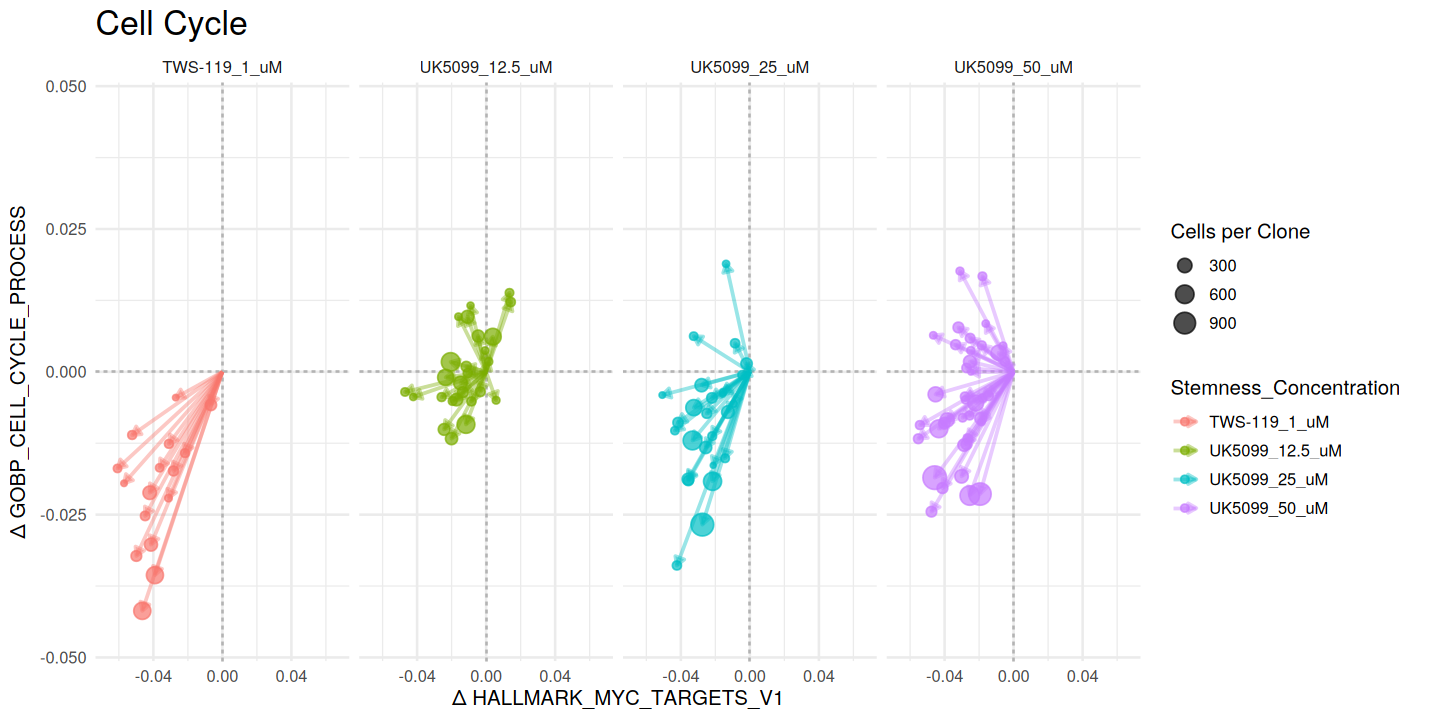

In [48]:
options(repr.plot.width = 12, repr.plot.height = 6)
plot_clonal_deltas(seurat_obj = so, path_x = 'HALLMARK_MYC_TARGETS_V1_UCell',path_y = 'GOBP_CELL_CYCLE_PROCESS_UCell', plot_title = 'Cell Cycle')

In [49]:
# Open the PDF graphics device
pdf("plots/Fig2h_clone_dynamics_with_legend.pdf", width = 12, height = 20) # You can specify width and height in inches

# Create your plot
plot_clonal_deltas(seurat_obj = so, path_x = 'HALLMARK_MYC_TARGETS_V1_UCell',path_y = 'GOBP_CELL_CYCLE_PROCESS_UCell', plot_title = 'Cell Cycle')

# Close the graphics device to save the plot
dev.off()

Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Δ HALLMARK_MYC_TARGETS_V1' in 'mbcsToSbcs': for Δ (U+0394)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Δ GOBP_CELL_CYCLE_PROCESS' in 'mbcsToSbcs': for Δ (U+0394)”


agg_record_81393171 
                  2